# Number Partitioning with QAOA — a `qcoptlib` demo

**Library demo · quantum-optimization repo**

A small, self-contained demonstration of the `qcoptlib` pipeline on a classic NP-hard problem:
**number partitioning** — split a set of values into two groups whose sums are as equal as
possible. The friendly framing is *fairly dividing an inheritance* between two siblings.

This notebook is thin by design: all the logic lives in `qcoptlib`. The notebook builds the
problem, solves it with QAOA, and checks the answer against brute force.

    values  ->  partition_qubo (qcoptlib.qubo)  ->  solve_qubo_qaoa (qcoptlib.quantum)  ->  decode + verify


## 1. The problem

Give each value a group (A or B). The **difference** between the two group sums is
`D = Σ vᵢ sᵢ` with `sᵢ = ±1`. We minimise `D²`, which expands into a sum of pairwise `ZᵢZⱼ`
terms weighted by `vᵢvⱼ` — a clean QUBO/Ising cost. `qcoptlib.qubo.partition_qubo` builds it.

The values below are chosen to split *perfectly* into two piles of \$57M each — a satisfying
ground truth to verify against.

In [1]:
from qcoptlib.qubo import partition_qubo, split_from_bits

# 13 property values (in $M). These happen to partition exactly.
values = [1, 5, 17, 1.5, 4.3, 13.8, 2, 2.3, 8.9, 21.9, 4.5, 7.1, 24.7]
print(f"{len(values)} values, total ${sum(values)}M, ideal half ${sum(values)/2}M")

qubo = partition_qubo(values)
print(f"QUBO: {qubo.n} binary variables (one per value)")


13 values, total $114.0M, ideal half $57.0M
QUBO: 13 binary variables (one per value)


## 2. Classical ground truth

Small enough (2¹³ splits) to brute-force the exact best split — the benchmark for QAOA.

In [2]:
best_bits, best_energy = qubo.brute_force()
group_a, group_b, gap = split_from_bits(best_bits, values)
print(f"Best split gap: ${gap:.2f}M")
print(f"  Group A (${sum(group_a):.1f}M): {sorted(group_a, reverse=True)}")
print(f"  Group B (${sum(group_b):.1f}M): {sorted(group_b, reverse=True)}")


Best split gap: $0.00M
  Group A ($57.0M): [17, 13.8, 7.1, 5, 4.5, 4.3, 2.3, 2, 1]
  Group B ($57.0M): [24.7, 21.9, 8.9, 1.5]


## 3. Solve with QAOA

`solve_qubo_qaoa` converts the QUBO to an Ising cost, builds the QAOA circuit, tunes the angles
(adiabatic-inspired init + a couple of restarts), and reads out the best sampled bitstring —
scored by the real objective, so a weakly-concentrated distribution still yields a good answer.
Runs on the Qiskit/Aer simulator (no account needed).

In [3]:
from qcoptlib.quantum.qiskit_backend import solve_qubo_qaoa

res = solve_qubo_qaoa(qubo, num_layers=3, maxiter=150, shots=8192, restarts=3, seed=0)

qa, qb, qgap = split_from_bits(res.best_bits, values)
print(f"QAOA split gap: ${qgap:.2f}M")
print(f"  Group A (${sum(qa):.1f}M): {sorted(qa, reverse=True)}")
print(f"  Group B (${sum(qb):.1f}M): {sorted(qb, reverse=True)}")
print()
print("Matches the optimum!" if qgap <= gap + 1e-6 else f"Gap ${qgap:.2f}M vs optimum ${gap:.2f}M")


QAOA split gap: $0.00M
  Group A ($57.0M): [21.9, 8.9, 7.1, 5, 4.5, 4.3, 2.3, 2, 1]
  Group B ($57.0M): [24.7, 17, 13.8, 1.5]

Matches the optimum!


## 4. Visualize the split

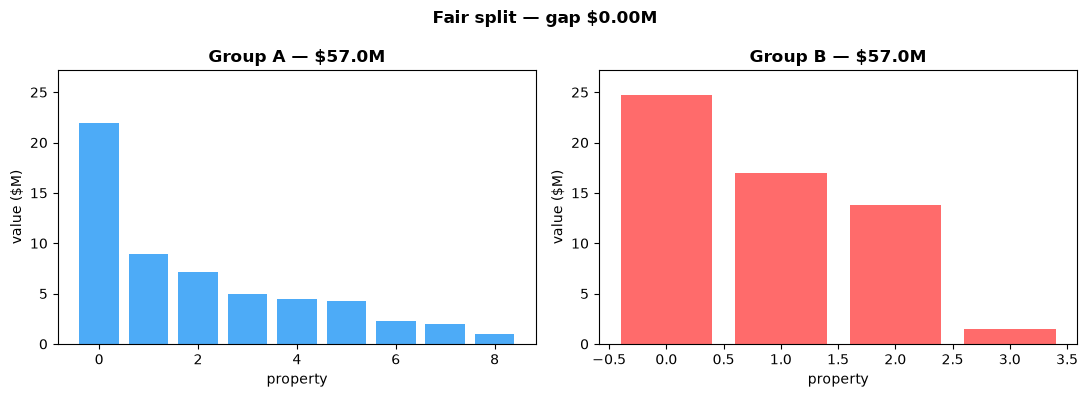

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, pile, title, color in [
    (ax[0], sorted(qa, reverse=True), f"Group A — ${sum(qa):.1f}M", "#4dabf7"),
    (ax[1], sorted(qb, reverse=True), f"Group B — ${sum(qb):.1f}M", "#ff6b6b"),
]:
    a.bar(range(len(pile)), pile, color=color)
    a.set_title(title, fontweight="bold")
    a.set_xlabel("property"); a.set_ylabel("value ($M)")
    a.set_ylim(0, max(values) * 1.1)
plt.suptitle(f"Fair split — gap ${qgap:.2f}M", fontweight="bold")
plt.tight_layout(); plt.show()


## 5. Why this is a good demo

- **A real NP-hard problem** (number partitioning), not a toy — but small enough that QAOA
  solves it cleanly and we can verify against brute force.
- **The encoding is textbook-clean**: `D²` → pairwise `ZᵢZⱼ` terms, one call to `partition_qubo`.
- **Honest scaling note**: at 13 values brute force wins instantly; QAOA's interest is at scales
  where 2ⁿ splits become uncheckable. Demonstrating the full pipeline end-to-end, verified, is
  the point.

The same `qcoptlib` pipeline (`QUBO` → `solve_qubo_qaoa`) powers every problem in the portfolio —
this is just its smallest, clearest instance.


---

# Part II — Dividing under uncertainty

Part I split the estate by **today's** value and found a perfect \$57M / \$57M cut. But an
inheritance is not cash — it is *assets whose future value is uncertain*. The Tel Aviv house is
worth `μ ± σ`; the startup equity might double or go to zero. A split that is perfectly fair
*today* can become badly unfair once the values move.

Meet the siblings: **Dana** and **Yonatan** inherit 13 assets. We now attach to each asset a
**volatility** (a standard deviation `σ`, as a fraction of its value), so real estate and equities
carry real risk while cash and government bonds barely move.

In [5]:
import numpy as np

# name, value ($M), volatility (std as a fraction of value)
assets = [
    ("Tel Aviv house",       24.7, 0.30),
    ("Herzliya apartment",   21.9, 0.28),
    ("Tech-stock portfolio", 17.0, 0.40),
    ("Startup equity",       13.8, 0.55),
    ("Rental duplex",         8.9, 0.22),
    ("Farmland",              7.1, 0.18),
    ("Corporate bonds",       5.0, 0.06),
    ("Vintage cars",          4.5, 0.35),
    ("Art collection",        4.3, 0.45),
    ("Gold & commodities",    2.3, 0.20),
    ("Government bonds",      2.0, 0.03),
    ("Cash savings",          1.5, 0.01),
    ("Crypto wallet",         1.0, 0.80),
]
names   = [a[0] for a in assets]
means   = np.array([a[1] for a in assets])          # μ, same 13 values as Part I
sigma   = np.array([a[2] for a in assets]) * means  # standard deviation in $M
var     = sigma ** 2                                 # σ², what the QUBO uses

print(f"Estate: ${means.sum():.0f}M total, ideal half ${means.sum()/2:.0f}M")
for nm, m, s in zip(names, means, sigma):
    print(f"  {nm:22s} ${m:5.1f}M  ± ${s:4.1f}M")


Estate: $114M total, ideal half $57M
  Tel Aviv house         $ 24.7M  ± $ 7.4M
  Herzliya apartment     $ 21.9M  ± $ 6.1M
  Tech-stock portfolio   $ 17.0M  ± $ 6.8M
  Startup equity         $ 13.8M  ± $ 7.6M
  Rental duplex          $  8.9M  ± $ 2.0M
  Farmland               $  7.1M  ± $ 1.3M
  Corporate bonds        $  5.0M  ± $ 0.3M
  Vintage cars           $  4.5M  ± $ 1.6M
  Art collection         $  4.3M  ± $ 1.9M
  Gold & commodities     $  2.3M  ± $ 0.5M
  Government bonds       $  2.0M  ± $ 0.1M
  Cash savings           $  1.5M  ± $ 0.0M
  Crypto wallet          $  1.0M  ± $ 0.8M


## 5. The trap: independent variance changes *nothing*

The natural first idea is "minimise the expected squared gap". Write the gap as
$D = \sum_i v_i s_i$ with $s_i = \pm 1$ (which sibling gets asset $i$). If the assets are
**independent**, then

$$\mathbb{E}[D^2] = \Big(\sum_i \mu_i s_i\Big)^2 + \sum_i \sigma_i^2.$$

The variance term $\sum_i \sigma_i^2$ is a **constant** — it does not depend on the assignment
$s$ at all (because $s_i^2 = 1$). So adding independent per-asset variance to the split
objective leaves the optimum **exactly** where it was. This is genuinely counter-intuitive, and
worth proving to yourself rather than taking on faith.

In [6]:
from qcoptlib.qubo import partition_qubo, stochastic_partition_qubo, split_from_bits, split_report

value_only = np.array(partition_qubo(list(means)).brute_force()[0])

# "robustness" term built on INDEPENDENT variances (gap-variance objective, γ = 5)
independent = np.array(
    stochastic_partition_qubo(means, variances=var, robust_weight=5.0).brute_force()[0]
)

same = np.array_equal(value_only, independent)
print("Independent-variance optimum identical to value-only optimum?", same)
print("→ independent per-asset variance cannot move the split. It has to enter differently.")


Independent-variance optimum identical to value-only optimum? True
→ independent per-asset variance cannot move the split. It has to enter differently.


## 6. What *does* work: balancing risk

The fix is to change the fairness goal. Fair-by-value is not the same as fair-by-**risk**: one
sibling can hold assets summing to \$57M that swing wildly, while the other holds \$57M of near-cash.
So we add a *second* balance objective — on the variances — and minimise both at once:

$$\underbrace{\Big(\sum_i \mu_i s_i\Big)^2}_{\text{equal value}} \;+\; \lambda \underbrace{\Big(\sum_i \sigma_i^2 s_i\Big)^2}_{\text{equal risk}}.$$

The second term is *itself* a number-partitioning problem, on the risk contributions — so it maps
onto a QUBO the same way, and the two just **add** (QUBOs compose). `λ` dials how much we care about
fair risk versus fair value. Because both terms live in the same variables, one solve handles both.

In [7]:
# λ = 0.5: care about risk balance, but not at the cost of value fairness
risk_balanced = np.array(
    stochastic_partition_qubo(means, variances=var, risk_weight=0.5).brute_force()[0]
)

rv = split_report(value_only,    means, variances=var)
rb = split_report(risk_balanced, means, variances=var)

def describe(tag, bits, r):
    A = [names[i] for i in r.idx_a]
    B = [names[i] for i in r.idx_b]
    print(f"{tag}")
    print(f"  Dana    : value ${r.value_a:5.1f}M   risk ±${r.risk_a:4.1f}M   {A}")
    print(f"  Yonatan : value ${r.value_b:5.1f}M   risk ±${r.risk_b:4.1f}M   {B}")
    print(f"  value gap ${r.value_gap:.2f}M   |   risk gap ${r.risk_gap:.2f}M\n")

describe("Value-only split (Part I):", value_only, rv)
describe("Risk-balanced split (λ=0.5):", risk_balanced, rb)
print(f"Risk imbalance cut from ${rv.risk_gap:.2f}M to ${rb.risk_gap:.2f}M, "
      f"value stays perfectly fair (${rb.value_gap:.2f}M gap).")


Value-only split (Part I):
  Dana    : value $ 57.0M   risk ±$11.0M   ['Tel Aviv house', 'Startup equity', 'Rental duplex', 'Art collection', 'Gold & commodities', 'Government bonds', 'Crypto wallet']
  Yonatan : value $ 57.0M   risk ±$ 9.4M   ['Herzliya apartment', 'Tech-stock portfolio', 'Farmland', 'Corporate bonds', 'Vintage cars', 'Cash savings']
  value gap $0.00M   |   risk gap $1.61M

Risk-balanced split (λ=0.5):
  Dana    : value $ 57.0M   risk ±$10.2M   ['Tel Aviv house', 'Tech-stock portfolio', 'Corporate bonds', 'Vintage cars', 'Gold & commodities', 'Government bonds', 'Cash savings']
  Yonatan : value $ 57.0M   risk ±$10.2M   ['Herzliya apartment', 'Startup equity', 'Rental duplex', 'Farmland', 'Art collection', 'Crypto wallet']
  value gap $0.00M   |   risk gap $0.06M

Risk imbalance cut from $1.61M to $0.06M, value stays perfectly fair ($0.00M gap).


The split **changed** — some assets moved siblings — and yet both bundles are still worth \$57M.
What improved is that the *volatility* is now shared evenly, so neither sibling is quietly carrying
all the risk. That is a different, and more honest, notion of a fair inheritance.

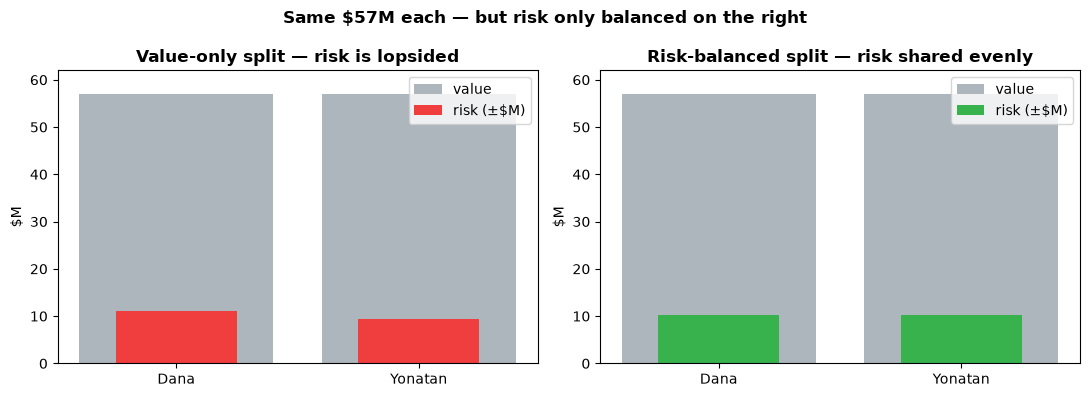

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
labels = ["Dana", "Yonatan"]

ax[0].bar(labels, [rv.value_a, rv.value_b], color="#adb5bd", label="value")
ax[0].bar(labels, [rv.risk_a, rv.risk_b], color="#f03e3e", width=0.5, label="risk (±$M)")
ax[0].set_title("Value-only split — risk is lopsided", fontweight="bold")
ax[0].set_ylabel("$M"); ax[0].legend()

ax[1].bar(labels, [rb.value_a, rb.value_b], color="#adb5bd", label="value")
ax[1].bar(labels, [rb.risk_a, rb.risk_b], color="#37b24d", width=0.5, label="risk (±$M)")
ax[1].set_title("Risk-balanced split — risk shared evenly", fontweight="bold")
ax[1].set_ylabel("$M"); ax[1].legend()

for a in ax:
    a.set_ylim(0, 62)
plt.suptitle("Same $57M each — but risk only balanced on the right", fontweight="bold")
plt.tight_layout(); plt.show()


## 7. The full pipeline still applies — solve it with QAOA

The risk-balanced problem is still a QUBO over the same 13 variables, so the *exact same*
`qcoptlib` quantum pipeline solves it. We read out the best sampled bitstring by real objective
(robust to weak QAOA concentration) and check it against the brute-force optimum.

In [9]:
from qcoptlib.quantum.qiskit_backend import solve_qubo_qaoa

qubo_rb = stochastic_partition_qubo(means, variances=var, risk_weight=0.5)
res = solve_qubo_qaoa(qubo_rb, num_layers=3, maxiter=150, shots=8192, restarts=3, seed=0)

qaoa_bits = np.array(res.best_bits)
rq = split_report(qaoa_bits, means, variances=var)
print(f"QAOA  : value gap ${rq.value_gap:.2f}M   risk gap ${rq.risk_gap:.2f}M")
print(f"Brute : value gap ${rb.value_gap:.2f}M   risk gap ${rb.risk_gap:.2f}M")
matched = np.isclose(qubo_rb.energy(qaoa_bits), qubo_rb.energy(risk_balanced))
print("QAOA reached the optimal objective." if matched else
      "QAOA found a good (not optimal) split — expected at NISQ scale; the read-out keeps the best sample.")


QAOA  : value gap $0.20M   risk gap $0.06M
Brute : value gap $0.00M   risk gap $0.06M
QAOA found a good (not optimal) split — expected at NISQ scale; the read-out keeps the best sample.


---

# Part III — When assets move together: correlations

The "trap" only holds for *independent* assets. If asset values are **correlated** — two Tel Aviv
properties rise and fall with the same market — then the gap variance

$$\mathrm{Var}(D) = s^\top C\, s$$

genuinely depends on the split (through the off-diagonal covariances $C_{ij}$), and minimising it
becomes a real optimization. It rewards putting positively-correlated assets on **opposite**
siblings, so their swings cancel in the *difference* and the split stays fair across market
scenarios. Here is the mechanism on a clean 4-asset example.

In [10]:
from qcoptlib.qubo import gap_variance_qubo

# 4 equal-value assets; assets 0 and 1 are almost perfectly correlated, 2 and 3 independent.
mu4 = np.array([10.0, 10.0, 10.0, 10.0])
s4  = np.array([2.0, 2.0, 2.0, 2.0])          # equal volatility
C4  = np.diag(s4 ** 2)
C4[0, 1] = C4[1, 0] = 0.95 * s4[0] * s4[1]     # strong positive correlation between 0 and 1

robust = np.array(stochastic_partition_qubo(mu4, cov=C4, robust_weight=1.0).brute_force()[0])
opposite = (robust[0] == 0) != (robust[1] == 0)
print("Correlated assets 0 and 1 placed on opposite siblings?", opposite)
print("→ correlation is what makes the *robust* split differ from a naive one.")


Correlated assets 0 and 1 placed on opposite siblings? True
→ correlation is what makes the *robust* split differ from a naive one.


### On the full estate

Treat the three Israeli real-estate assets — the Tel Aviv house, the Herzliya apartment and the
rental duplex — as strongly correlated (one property market). The robustness term then prefers a
split that spreads them across the siblings, lowering how much the \$57M/\$57M gap can drift if
that market moves.

In [11]:
# build a covariance with the 3 real-estate assets correlated (indices 0, 1, 4)
C = np.diag(var).astype(float)
re_idx = [0, 1, 4]
rho = 0.85
for a in re_idx:
    for b in re_idx:
        if a < b:
            C[a, b] = C[b, a] = rho * sigma[a] * sigma[b]

robust_estate = np.array(stochastic_partition_qubo(means, cov=C, robust_weight=0.5).brute_force()[0])
r_rob = split_report(robust_estate, means, cov=C)
r_val = split_report(value_only,    means, cov=C)

def side(bits, i):  # which sibling holds asset i
    return "Dana" if bits[i] == 0 else "Yonatan"

print("Real estate placement (robust split):")
for i in re_idx:
    print(f"  {names[i]:22s} -> {side(robust_estate, i)}")
print(f"\nGap volatility  value-only: ±${r_val.gap_std:.2f}M   robust: ±${r_rob.gap_std:.2f}M")
print("The robust split separates the correlated properties and steadies the gap.")


Real estate placement (robust split):
  Tel Aviv house         -> Yonatan
  Herzliya apartment     -> Dana
  Rental duplex          -> Dana

Gap volatility  value-only: ±$11.66M   robust: ±$11.29M
The robust split separates the correlated properties and steadies the gap.


**Honest note.** On this particular estate the gap-volatility improvement is modest — the
value-only split already happened to spread the properties somewhat, and one solve cannot beat the
structure of the data. The point is the *mechanism* and the *dials*: `risk_weight` (λ) buys fair
risk exposure, `robust_weight` (γ) buys a gap that stays fair when correlated markets move, and
both compose onto the same QUBO the deterministic split already used.

---

# Part IV — What this adds

Part I was a clean demonstration of the pipeline. Parts II–III turn it into a small study in
**optimization under uncertainty**:

- **A real modelling insight, proved not asserted:** independent per-asset variance cannot change
  a min-squared-gap split (the constant-variance trap). Recognising *why* an objective is blind to
  the data it was given is exactly the kind of reasoning that separates a working model from a
  plausible-looking one.
- **Multi-objective QUBO composition:** value fairness, risk balance, and gap robustness are three
  objectives that simply **add** (`QUBO.__add__` / `.scaled`), each with an interpretable weight.
- **Stochastic and robust optimization**, mapped onto the same QUBO → QAOA pipeline as the
  deterministic problem — no new machinery, just a richer cost.

Same `qcoptlib` throughout: `stochastic_partition_qubo` builds the cost, brute force gives ground
truth, `solve_qubo_qaoa` runs the quantum pipeline, `split_report` reads out fairness in both value
and risk.